# Vision Model Clustering

Compares embedding and cluster structure across CLIP and CLIP-successor families on a full
screenshot corpus. Covers throughput benchmarking, full-corpus embedding, pairwise cluster
agreement, and cross-family efficiency analysis.

Embeddings are cached per model to `data/notebook/models/` keyed by model name and input path
signature. Repeat runs skip recomputation unless the corpus or model list changes.

In [1]:
import hashlib
import time
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import list_models
from PIL import Image
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import pair_confusion_matrix
from tqdm import tqdm

from bruki.config import load_config, resolve_paths
from bruki.embed import (
    ClusterConfig,
    EmbedConfig,
    cluster_embeddings,
    encode_features,
    load_model,
    load_or_embed,
    prepare_image,
)

warnings.filterwarnings(
    "ignore",
    message=r"n_jobs value .* overridden to 1 by setting random_state",
    category=UserWarning,
    module=r"umap\.umap_",
)

Model specs and run parameters are defined once here so every downstream table and plot is
directly comparable. `MODEL_SPECS` is the single source of truth for which models run and in
what order. Constants controlling UMAP and HDBSCAN are fixed across all models--any parameter
change invalidates cached cluster results but not cached embeddings.

In [2]:
ROOT = Path.cwd().parent
CONFIG_PATH = ROOT / "config.yaml"

MODEL_CACHE_ROOT = ROOT / "data/notebook/models"
MODEL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

PERF_N = 20

SEED = 42
MIN_SIZE = 10
CHECKPOINT_EVERY = 100

UMAP_N_COMPONENTS = 2
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"

HDBSCAN_MIN_CLUSTER_SIZE = 10
HDBSCAN_MIN_SAMPLES = 5
HDBSCAN_METRIC = "euclidean"

OPENAI_CLIP_MODELS = sorted(
    m.modelId
    for m in list_models(filter="clip", author="openai")
    if m.modelId.startswith("openai/clip-vit-")
)

MODEL_SPECS = [
    *[
        {
            "name": model_name,
            "backend": "hf",
            "family": "clip",
        }
        for model_name in OPENAI_CLIP_MODELS
    ],
    {"name": "google/siglip-base-patch16-224", "backend": "hf", "family": "siglip"},
    {"name": "google/siglip-base-patch16-256", "backend": "hf", "family": "siglip"},
    {"name": "google/siglip-large-patch16-256", "backend": "hf", "family": "siglip"},
    {"name": "facebook/metaclip-b32-400m", "backend": "hf", "family": "clip"},
    {"name": "facebook/dinov2-small", "backend": "hf", "family": "dinov2"},
    {"name": "apple/MobileCLIP-B-OpenCLIP", "backend": "open_clip_hf", "family": "open_clip"},
]

MODELS = [spec["name"] for spec in MODEL_SPECS]

print(f"models loaded ({len(MODEL_SPECS)}):")
for spec in MODEL_SPECS:
    print(f"{spec['name']} [{spec['family']}/{spec['backend']}]")

models loaded (10):
openai/clip-vit-base-patch16 [clip/hf]
openai/clip-vit-base-patch32 [clip/hf]
openai/clip-vit-large-patch14 [clip/hf]
openai/clip-vit-large-patch14-336 [clip/hf]
google/siglip-base-patch16-224 [siglip/hf]
google/siglip-base-patch16-256 [siglip/hf]
google/siglip-large-patch16-256 [siglip/hf]
facebook/metaclip-b32-400m [clip/hf]
facebook/dinov2-small [dinov2/hf]
apple/MobileCLIP-B-OpenCLIP [open_clip/open_clip_hf]


Corpus is resolved and shuffled once with a fixed seed. All models operate on the same ordered
path list so valid-index alignment across models is deterministic.

In [3]:
config    = load_config(str(CONFIG_PATH))
groups    = resolve_paths(config, series=config.plots["screenshots"].series)
all_paths = [path for _, _, source_paths in groups for path in source_paths]
all_paths = list(dict.fromkeys(all_paths))

rng       = np.random.default_rng(SEED)
order     = rng.permutation(len(all_paths))
all_paths = [all_paths[i] for i in order]

print(f"resolved screenshots: {len(all_paths)}")

resolved screenshots: 2909


Model loading is dispatched by backend and family. `open_clip_hf` models load through the
`open_clip` package; all others go through `transformers` via a dispatch table keyed on family
name. Model initialization is isolated from embedding so one-time load overhead is visible in
timing output when it occurs.

In [4]:
EMBED_CONFIG = EmbedConfig(
    min_size=MIN_SIZE,
    checkpoint_every=CHECKPOINT_EVERY,
)

CLUSTER_CONFIG = ClusterConfig(
    umap_n_components=UMAP_N_COMPONENTS,
    umap_n_neighbors=UMAP_N_NEIGHBORS,
    umap_min_dist=UMAP_MIN_DIST,
    umap_metric=UMAP_METRIC,
    hdbscan_min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    hdbscan_min_samples=HDBSCAN_MIN_SAMPLES,
    hdbscan_metric=HDBSCAN_METRIC,
    seed=SEED,
)

Feature extraction is normalized to unit vectors at the exit point of `encode_features`
regardless of family. `_cls_token` handles the two output shapes that appear across families:
`pooler_output` where present, `last_hidden_state[:, 0]` otherwise.

Embeddings are cached per model to a `.pkl` keyed by model name. On load, cached paths are
aligned against the current path list by position lookup--paths present in cache are restored
directly, missing paths are queued for embedding. Checkpoints are written every
`CHECKPOINT_EVERY` images so an interrupted run restarts from the last checkpoint rather than
from scratch. Cache state is reported as `hit`, `partial`, or `miss`.

The performance path (`embed_uncached`) bypasses cache entirely so benchmark timings reflect
true model throughput rather than I/O.

`stable_sample_paths` selects a reproducible subset by hashing each path against a salt, giving
a deterministic sample that is stable across corpus additions without relying on sort order.

In [5]:
def embed_uncached(spec: dict, paths: list[Path]):
    model_name = spec["name"]
    model, processor, device = load_model(spec)
    path_strings = [str(p) for p in paths]
    n = len(path_strings)
    embeddings = None
    valid_mask = np.zeros(n, dtype=bool)
    started = time.perf_counter()

    with torch.inference_mode():
        for i in tqdm(range(n), desc=f"embed:{model_name}"):
            image = prepare_image(Path(path_strings[i]), EMBED_CONFIG)
            if image is None:
                valid_mask[i] = False
                continue
            vec = encode_features(spec, model, processor, image, device).cpu().numpy()[
                0].astype(np.float32)
            if embeddings is None:
                embeddings = np.zeros((n, vec.shape[0]), dtype=np.float32)
            embeddings[i] = vec
            valid_mask[i] = True

    elapsed = time.perf_counter() - started
    if embeddings is None:
        embeddings = np.zeros((n, 0), dtype=np.float32)
    result = {"paths": path_strings, "embeddings": embeddings, "valid_mask": valid_mask}
    return {**result, "elapsed_s": elapsed}, "none"


def stable_sample_paths(paths: list[Path], n: int, salt: str = "perf-v1") -> list[Path]:
    if n < 0:
        return paths
    scored = sorted(
        paths,
        key=lambda p: hashlib.sha256(f"{salt}:{p.as_posix()}".encode()).hexdigest(),
    )
    return scored[: min(n, len(scored))]


def run_models(n: int = -1, perf: bool = False, do_cluster: bool = True):
    paths = stable_sample_paths(all_paths, n)
    model_runs = {}
    summary_rows = []

    print(
        f"running models: {len(MODEL_SPECS)} | n={len(paths)} | perf={perf} | cluster={do_cluster}")
    for spec in MODEL_SPECS:
        model_name = spec["name"]
        print(f"start: {model_name}")
        if perf:
            result, cache_state = embed_uncached(spec, paths)
        else:
            result, cache_state = load_or_embed(spec, paths, MODEL_CACHE_ROOT, EMBED_CONFIG)

        embeddings = np.asarray(result["embeddings"], dtype=np.float32)
        valid_mask = np.asarray(result["valid_mask"], dtype=bool)
        valid_indices = np.where(valid_mask)[0]
        valid_embeddings = embeddings[valid_mask]

        cluster_elapsed = 0.0
        n_clusters = np.nan
        noise_points = np.nan
        noise_rate = np.nan

        if do_cluster:
            if valid_embeddings.shape[0] < 2:
                raise RuntimeError(f"Not enough valid embeddings for {model_name}")

            cluster_started = time.perf_counter()
            embedding_2d, labels = cluster_embeddings(valid_embeddings, CLUSTER_CONFIG)
            cluster_elapsed = time.perf_counter() - cluster_started

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_points = int((labels == -1).sum())
            noise_rate = float((labels == -1).mean())
            model_runs[model_name] = {
                "valid_indices": valid_indices,
                "labels": labels,
                "embedding_2d": embedding_2d,
                "valid_count": int(valid_mask.sum()),
            }

        summary_rows.append(
            {
                "model": model_name,
                "family": spec["family"],
                "backend": spec["backend"],
                "cache": cache_state,
                "resolved": len(paths),
                "valid": int(valid_mask.sum()),
                "dropped": int((~valid_mask).sum()),
                "embed_s": float(result["elapsed_s"]),
                "cluster_s": float(cluster_elapsed),
                "total_min": (float(result["elapsed_s"]) + float(cluster_elapsed)) / 60.0,
                "clusters": n_clusters,
                "noise_points": noise_points,
                "noise_rate": noise_rate,
            }
        )
        print(
            f"done: {model_name} cache={cache_state} "
            f"embed_s={float(result['elapsed_s']):.2f} cluster_s={cluster_elapsed:.2f}"
        )

    summary = pd.DataFrame(summary_rows)
    summary["embed_s"] = summary["embed_s"].round(2)
    summary["cluster_s"] = summary["cluster_s"].round(2)
    summary["total_min"] = summary["total_min"].round(2)
    summary["noise_rate"] = summary["noise_rate"].round(4)
    summary["sec_per_image"] = (summary["embed_s"] / summary["resolved"]).round(4)
    summary["est_full_min"] = (summary["sec_per_image"] * len(all_paths) / 60.0).round(1)
    summary["est_full_hr"] = (summary["est_full_min"] / 60.0).round(2)
    summary = summary.sort_values("total_min").reset_index(drop=True)

    return model_runs, summary

### Performance run

Throughput is benchmarked on a fixed sample before committing to a full corpus run.
`perf_results` is a no-op if a valid CSV already exists at `PERF_CSV`. Set `RERUN_PERF = True`
to force a fresh benchmark. Results are sorted by `sec_per_image` and include a slowdown ratio
normalized to the fastest model.

In [6]:
PERF_N     = 100
RERUN_PERF = False
PERF_CSV   = ROOT / "data/notebook/perf/embed.csv"


def perf_results(n: int = PERF_N, rerun: bool = RERUN_PERF) -> pd.DataFrame:
    if PERF_CSV.exists() and not rerun:
        return pd.read_csv(PERF_CSV)
    _, summary = run_models(n=n, perf=True, do_cluster=False)
    df = summary[["model", "family", "backend",
                  "sec_per_image", "est_full_min", "est_full_hr"]].copy()
    df = df.sort_values("sec_per_image").reset_index(drop=True)
    df["speed_vs_fastest_x"] = (df["sec_per_image"] / df["sec_per_image"].min()).round(2)
    df = df[["model", "family", "backend", "speed_vs_fastest_x",
             "sec_per_image", "est_full_min", "est_full_hr"]]
    df.to_csv(PERF_CSV, index=False)
    return df


perf_results()

,model,family,backend,speed_vs_fastest_x,sec_per_image,est_full_min,est_full_hr
0,facebook/metaclip-b32-400m,clip,hf,1.00,0.1017,4.9,0.08
1,openai/clip-vit-base-patch32,clip,hf,1.12,0.1139,5.5,0.09
2,facebook/dinov2-small,dinov2,hf,1.14,0.1164,5.6,0.09
3,openai/clip-vit-base-patch16,clip,hf,2.39,0.2427,11.8,0.20
4,apple/MobileCLIP-B-OpenCLIP,open_clip,open_clip_hf,2.43,0.2473,12.0,0.20
5,google/siglip-base-patch16-224,siglip,hf,2.72,0.2765,13.4,0.22
6,google/siglip-base-patch16-256,siglip,hf,3.29,0.3346,16.2,0.27
7,openai/clip-vit-large-patch14,clip,hf,11.17,1.1363,55.1,0.92
8,google/siglip-large-patch16-256,siglip,hf,11.54,1.1741,56.9,0.95
9,openai/clip-vit-large-patch14-336,clip,hf,22.36,2.2738,110.2,1.84


### Production run

Full corpus embedding and clustering for all models. All embeddings are loaded from cache on
subsequent runs. Cluster metrics (count, noise points, noise rate) are computed per model and
appended to the summary. Runtime is reported split between embed and cluster phases.

In [7]:
model_runs, run_summary = run_models(n=-1, perf=False, do_cluster=True)

# print("run_summary:")
# print(run_summary.to_string(index=False))
run_summary

running models: 10 | n=2909 | perf=False | cluster=True
start: openai/clip-vit-base-patch16


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
embed:openai/clip-vit-base-patch16: 100%|██████████████████████████████████| 3/3 [00:00<00:00,  4.22it/s]


done: openai/clip-vit-base-patch16 cache=partial embed_s=0.71 cluster_s=13.23
start: openai/clip-vit-base-patch32


...

embed:facebook/dinov2-small: 100%|█████████████████████████████████████████| 3/3 [00:00<00:00, 12.61it/s]


done: facebook/dinov2-small cache=partial embed_s=0.25 cluster_s=8.08
start: apple/MobileCLIP-B-OpenCLIP


embed:apple/MobileCLIP-B-OpenCLIP: 100%|███████████████████████████████████| 3/3 [00:00<00:00,  9.68it/s]


done: apple/MobileCLIP-B-OpenCLIP cache=partial embed_s=0.31 cluster_s=9.01


,model,family,backend,cache,resolved,valid,dropped,embed_s,cluster_s,total_min,clusters,noise_points,noise_rate,sec_per_image,est_full_min,est_full_hr
0,facebook/dinov2-small,dinov2,hf,partial,2909,2907,2,0.25,8.08,0.14,88,755,0.2597,0.0001,0.0,0.0
1,openai/clip-vit-base-patch32,clip,hf,partial,2909,2907,2,0.59,9.04,0.16,87,648,0.2229,0.0002,0.0,0.0
2,apple/MobileCLIP-B-OpenCLIP,open_clip,open_clip_hf,partial,2909,2907,2,0.31,9.01,0.16,90,653,0.2246,0.0001,0.0,0.0
3,facebook/metaclip-b32-400m,clip,hf,partial,2909,2907,2,0.48,9.51,0.17,78,645,0.2219,0.0002,0.0,0.0
4,google/siglip-base-patch16-256,siglip,hf,partial,2909,2907,2,0.69,10.41,0.19,91,553,0.1902,0.0002,0.0,0.0
5,openai/clip-vit-large-patch14,clip,hf,partial,2909,2907,2,1.14,10.21,0.19,93,582,0.2002,0.0004,0.0,0.0
6,google/siglip-base-patch16-224,siglip,hf,partial,2909,2907,2,0.76,10.69,0.19,90,650,0.2236,0.0003,0.0,0.0
7,openai/clip-vit-large-patch14-336,clip,hf,partial,2909,2907,2,2.78,9.94,0.21,86,573,0.1971,0.0010,0.0,0.0
8,google/siglip-large-patch16-256,siglip,hf,partial,2909,2907,2,1.56,11.47,0.22,98,598,0.2057,0.0005,0.0,0.0
9,openai/clip-vit-base-patch16,clip,hf,partial,2909,2907,2,0.71,13.23,0.23,97,653,0.2246,0.0002,0.0,0.0


Pairwise ARI and NMI are computed on shared valid rows only. `ari_all` includes noise-labeled
points; `ari_core` restricts to points both models assigned to a cluster. The gap between the
two is the primary structural signal: low `ari_all` with high `ari_core` indicates disagreement
concentrated at the noise boundary rather than in cluster interiors.

In [8]:
def iter_model_pairs(model_runs, models):
    for model_a, model_b in combinations(models, 2):
        idx_a = model_runs[model_a]["valid_indices"]
        idx_b = model_runs[model_b]["valid_indices"]
        _, pos_a, pos_b = np.intersect1d(idx_a, idx_b, return_indices=True)
        if pos_a.size < 2:
            yield model_a, model_b, None, None, None, None
            continue
        la = model_runs[model_a]["labels"][pos_a]
        lb = model_runs[model_b]["labels"][pos_b]
        core = (la != -1) & (lb != -1)
        la_core = la[core] if int(core.sum()) >= 2 else None
        lb_core = lb[core] if int(core.sum()) >= 2 else None
        yield model_a, model_b, la, lb, la_core, lb_core


pair_rows = []
for model_a, model_b, la, lb, la_c, lb_c in iter_model_pairs(model_runs, MODELS):
    row = {
        "model_a": model_a,
        "model_b": model_b,
        "shared_valid": 0 if la is None else int(la.size),
        "ari_all": np.nan,
        "nmi_all": np.nan,
        "ari_core": np.nan,
        "nmi_core": np.nan,
    }
    if la is not None:
        row["ari_all"] = adjusted_rand_score(la, lb)
        row["nmi_all"] = normalized_mutual_info_score(la, lb)
    if la_c is not None:
        row["ari_core"] = adjusted_rand_score(la_c, lb_c)
        row["nmi_core"] = normalized_mutual_info_score(la_c, lb_c)
    pair_rows.append(row)

pairwise = pd.DataFrame(pair_rows)
for col in ["ari_all", "nmi_all", "ari_core", "nmi_core"]:
    pairwise[col] = pairwise[col].round(4)
pairwise = pairwise.sort_values(["ari_all", "nmi_all"], ascending=False).reset_index(drop=True)
pairwise

,model_a,model_b,shared_valid,ari_all,nmi_all,ari_core,nmi_core
0,google/siglip-base-patch16-224,google/siglip-base-patch16-256,2907,0.2310,0.7119,0.7562,0.8991
1,openai/clip-vit-large-patch14,openai/clip-vit-large-patch14-336,2907,0.2296,0.7238,0.7154,0.9092
2,google/siglip-base-patch16-256,google/siglip-large-patch16-256,2907,0.1890,0.6938,0.6366,0.8791
3,google/siglip-base-patch16-224,google/siglip-large-patch16-256,2907,0.1888,0.6758,0.6372,0.8683
4,openai/clip-vit-base-patch16,openai/clip-vit-large-patch14,2907,0.1548,0.6526,0.5994,0.8503
5,google/siglip-base-patch16-256,apple/MobileCLIP-B-OpenCLIP,2907,0.1504,0.6224,0.6322,0.8197
6,openai/clip-vit-base-patch16,apple/MobileCLIP-B-OpenCLIP,2907,0.1457,0.6271,0.5436,0.8266
7,facebook/metaclip-b32-400m,apple/MobileCLIP-B-OpenCLIP,2907,0.1429,0.6037,0.5651,0.8201
8,google/siglip-base-patch16-224,apple/MobileCLIP-B-OpenCLIP,2907,0.1399,0.6001,0.5723,0.8046
9,openai/clip-vit-base-patch16,openai/clip-vit-base-patch32,2907,0.1392,0.6304,0.5490,0.8382


### Pair-level reproducibility

If two images are grouped together by one model, how often do they stay grouped together in
another? `pair_confusion_matrix` gives the four cells of the pair-contingency table in one
vectorized pass. TP = both models co-cluster the pair. FN = same cluster in A, different in B.
FP = different in A, same in B. Derived metrics: `retain_a_to_b` = TP / (TP+FN),
`retain_b_to_a` = TP / (TP+FP), `pair_jaccard` = TP / (TP+FP+FN). Only core points (non-noise
in both models) are used.

In [9]:
rows = []
for model_a, model_b, _la, _lb, la_c, lb_c in iter_model_pairs(model_runs, MODELS):
    if la_c is None:
        rows.append({
            "model_a": model_a,
            "model_b": model_b,
            "n_core": 0,
            "pairs_same_a": 0,
            "pairs_same_b": 0,
            "pairs_same_both": 0,
            "retain_a_to_b": np.nan,
            "retain_b_to_a": np.nan,
            "pair_jaccard": np.nan,
        })
        continue

    cm = pair_confusion_matrix(la_c, lb_c)
    tp = int(cm[1, 1])
    fn = int(cm[1, 0])
    fp = int(cm[0, 1])

    a_same = tp + fn
    b_same = tp + fp
    union  = tp + fp + fn

    rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "n_core": int(la_c.size),
        "pairs_same_a": a_same,
        "pairs_same_b": b_same,
        "pairs_same_both": tp,
        "retain_a_to_b": round(tp / a_same, 4) if a_same else np.nan,
        "retain_b_to_a": round(tp / b_same, 4) if b_same else np.nan,
        "pair_jaccard": round(tp / union, 4) if union else np.nan,
    })

co_cluster_retention = (
    pd.DataFrame(rows)
    .sort_values("pair_jaccard", ascending=False)
    .reset_index(drop=True)
)
co_cluster_retention

,model_a,model_b,n_core,pairs_same_a,pairs_same_b,pairs_same_both,retain_a_to_b,retain_b_to_a,pair_jaccard
0,google/siglip-base-patch16-224,google/siglip-base-patch16-256,1963,64402,63178,48498,0.7531,0.7676,0.6133
1,openai/clip-vit-large-patch14,openai/clip-vit-large-patch14-336,2002,56022,62624,42690,0.7620,0.6817,0.5620
2,google/siglip-base-patch16-224,google/siglip-large-patch16-256,1919,60194,48206,34822,0.5785,0.7224,0.4733
3,google/siglip-base-patch16-256,google/siglip-large-patch16-256,1983,63020,50796,36522,0.5795,0.7190,0.4725
4,google/siglip-base-patch16-256,apple/MobileCLIP-B-OpenCLIP,1906,61784,62976,39828,0.6446,0.6324,0.4689
5,openai/clip-vit-large-patch14-336,apple/MobileCLIP-B-OpenCLIP,1881,60424,57630,36590,0.6056,0.6349,0.4492
6,openai/clip-vit-base-patch16,openai/clip-vit-large-patch14,1906,48982,51508,30394,0.6205,0.5901,0.4336
7,openai/clip-vit-base-patch16,openai/clip-vit-large-patch14-336,1890,48542,56982,30818,0.6349,0.5408,0.4125
8,openai/clip-vit-large-patch14-336,google/siglip-base-patch16-256,1944,60590,60772,35396,0.5842,0.5824,0.4117
9,google/siglip-base-patch16-224,apple/MobileCLIP-B-OpenCLIP,1842,57916,57374,33412,0.5769,0.5824,0.4081


### Cross-family comparison

Within-family pairs are excluded. Performance data is joined from `perf/embed.csv` so each
pair carries a `perf_ratio_x` (slower model / faster model) and `pair_est_full_min` (combined
full-corpus cost). `siglip-so400m` is excluded as it was not run on the full corpus.

In [10]:
perf = pd.read_csv(ROOT / "data/notebook/perf/embed.csv")
perf = perf[["model", "sec_per_image", "est_full_min"]].copy()
perf = perf[perf["model"] != "google/siglip-so400m-patch14-384"].reset_index(drop=True)

fam = run_summary.set_index("model")["family"].to_dict()

pair_cf = (
    pairwise.assign(
        fam_a=lambda d: d["model_a"].map(fam),
        fam_b=lambda d: d["model_b"].map(fam),
    )
    .query("fam_a != fam_b")
    .drop(columns=["shared_valid"], errors="ignore")
)

ret_cf = (
    co_cluster_retention.assign(
        fam_a=lambda d: d["model_a"].map(fam),
        fam_b=lambda d: d["model_b"].map(fam),
    )
    .query("fam_a != fam_b")
    [["model_a", "model_b", "pair_jaccard", "retain_a_to_b", "retain_b_to_a", "n_core"]]
)

out = (
    pair_cf.merge(ret_cf, on=["model_a", "model_b"], how="inner")
    .merge(perf.add_prefix("a_"), left_on="model_a", right_on="a_model", how="left")
    .merge(perf.add_prefix("b_"), left_on="model_b", right_on="b_model", how="left")
    .drop(columns=["a_model", "b_model"])
    .assign(
        faster_sec=lambda d: d[["a_sec_per_image", "b_sec_per_image"]].min(axis=1),
        slower_sec=lambda d: d[["a_sec_per_image", "b_sec_per_image"]].max(axis=1),
        perf_ratio_x=lambda d: d["slower_sec"] / d["faster_sec"],
        pair_est_full_min=lambda d: d["a_est_full_min"] + d["b_est_full_min"],
    )
    .sort_values(["pair_jaccard", "ari_core"], ascending=False)
    .reset_index(drop=True)
)

cols = [
    "model_a", "model_b",
    "pair_jaccard", "ari_core",
    "perf_ratio_x", "pair_est_full_min",
]
out[cols].round(2)

,model_a,model_b,pair_jaccard,ari_core,perf_ratio_x,pair_est_full_min
0,google/siglip-base-patch16-256,apple/MobileCLIP-B-OpenCLIP,0.47,0.63,1.35,28.2
1,openai/clip-vit-large-patch14-336,apple/MobileCLIP-B-OpenCLIP,0.45,0.61,9.19,122.2
2,openai/clip-vit-large-patch14-336,google/siglip-base-patch16-256,0.41,0.58,6.80,126.4
3,google/siglip-base-patch16-224,apple/MobileCLIP-B-OpenCLIP,0.41,0.57,1.12,25.4
4,facebook/metaclip-b32-400m,apple/MobileCLIP-B-OpenCLIP,0.40,0.57,2.43,16.9
5,openai/clip-vit-large-patch14,apple/MobileCLIP-B-OpenCLIP,0.39,0.56,4.59,67.1
6,openai/clip-vit-base-patch16,apple/MobileCLIP-B-OpenCLIP,0.38,0.54,1.02,23.8
7,openai/clip-vit-base-patch32,apple/MobileCLIP-B-OpenCLIP,0.38,0.54,2.17,17.5
8,openai/clip-vit-large-patch14,google/siglip-large-patch16-256,0.38,0.54,1.03,112.0
9,openai/clip-vit-large-patch14-336,google/siglip-base-patch16-224,0.37,0.53,8.22,123.6


### Cross-family mean Jaccard vs runtime

Each model's mean cross-family Jaccard is its average pair Jaccard across all pairs where the
partner is from a different family. Plotted against `sec_per_image` on a log x-axis. The Pareto
front is constructed by sweeping models in ascending speed order and retaining those that
improve on the best Jaccard seen so far.

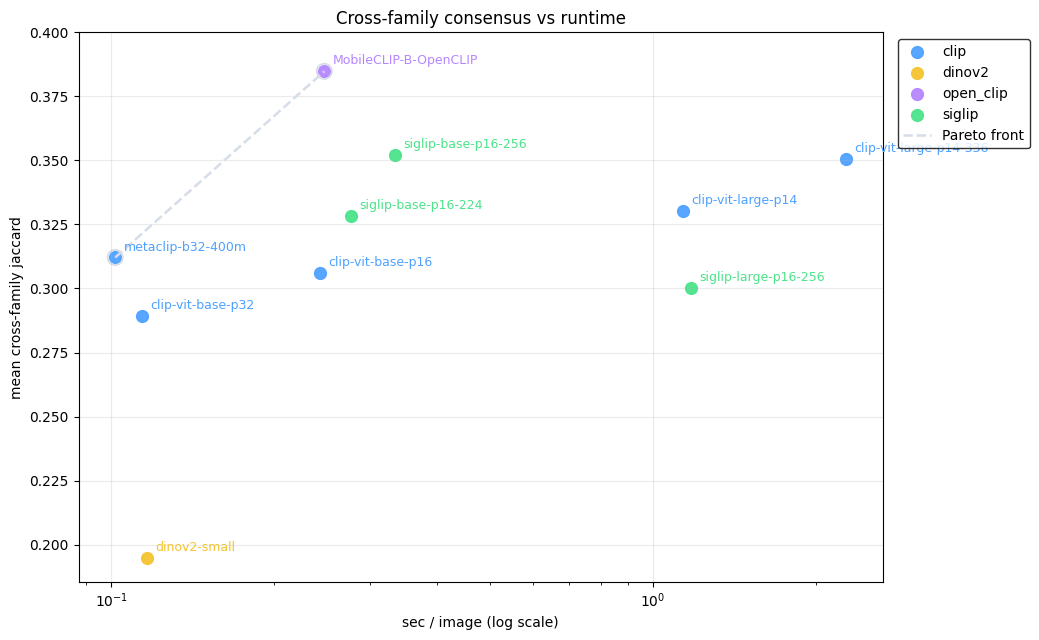

,model,mean_cross_family_jaccard,pairs,sec_per_image,family
4,apple/MobileCLIP-B-OpenCLIP,0.384778,9,0.2473,open_clip
6,google/siglip-base-patch16-256,0.352057,7,0.3346,siglip
9,openai/clip-vit-large-patch14-336,0.350680,5,2.2738,clip
7,openai/clip-vit-large-patch14,0.330180,5,1.1363,clip
5,google/siglip-base-patch16-224,0.328386,7,0.2765,siglip
0,facebook/metaclip-b32-400m,0.312100,5,0.1017,clip
3,openai/clip-vit-base-patch16,0.305900,5,0.2427,clip
8,google/siglip-large-patch16-256,0.300043,7,1.1741,siglip
1,openai/clip-vit-base-patch32,0.289360,5,0.1139,clip
2,facebook/dinov2-small,0.194856,9,0.1164,dinov2


In [11]:
left  = out[["model_a", "pair_jaccard"]].rename(columns={"model_a": "model"})
right = out[["model_b", "pair_jaccard"]].rename(columns={"model_b": "model"})
jaccard_mean = (
    pd.concat([left, right], ignore_index=True)
    .groupby("model", as_index=False)
    .agg(mean_cross_family_jaccard=("pair_jaccard", "mean"), pairs=("pair_jaccard", "size"))
)

family_map = run_summary.set_index("model")["family"].to_dict()
perf_plot = perf[["model", "sec_per_image"]].copy()
plot_df = (
    jaccard_mean.merge(perf_plot, on="model", how="inner")
    .assign(family=lambda d: d["model"].map(family_map).fillna("other"))
    .sort_values("sec_per_image")
    .reset_index(drop=True)
)

pareto = []
best_y = -1.0
for row in plot_df.itertuples(index=False):
    if row.mean_cross_family_jaccard > best_y:
        pareto.append((row.sec_per_image, row.mean_cross_family_jaccard))
        best_y = row.mean_cross_family_jaccard

family_colors = {
    "clip": "#4ea1ff",
    "siglip": "#4ce38a",
    "open_clip": "#b586ff",
    "dinov2": "#f4c430",
    "other": "#ff9f43",
}


def short_name(model: str) -> str:
    s = model.split("/")[-1]
    return s.replace("patch", "p").replace("OpenCLIP", "OpenCLIP")


fig, ax = plt.subplots(figsize=(10.5, 6.5))
ax.set_facecolor("white")

for family, grp in plot_df.groupby("family", sort=False):
    ax.scatter(
        grp["sec_per_image"],
        grp["mean_cross_family_jaccard"],
        s=72,
        color=family_colors.get(family, family_colors["other"]),
        label=family,
        alpha=0.95,
    )

for row in plot_df.itertuples(index=False):
    ax.annotate(
        short_name(row.model),
        (row.sec_per_image, row.mean_cross_family_jaccard),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
        color=family_colors.get(row.family, family_colors["other"]),
    )

if pareto:
    px = [p[0] for p in pareto]
    py = [p[1] for p in pareto]
    ax.plot(px, py, linestyle="--", linewidth=1.8, color="#d6dde8", label="Pareto front")
    ax.scatter(px, py, s=120, facecolors="none", edgecolors="#d6dde8", linewidths=1.3)

ax.set_xscale("log")
ax.set_xlabel("sec / image (log scale)")
ax.set_ylabel("mean cross-family jaccard")
ax.set_title("Cross-family consensus vs runtime")
ax.set_ylim(top=0.40)
# ax.set_ylim(bottom=0.25)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=True,
          facecolor="white", edgecolor="black", labelcolor="black")
plt.tight_layout()
plt.show()

plot_df.sort_values(["mean_cross_family_jaccard", "sec_per_image"], ascending=[False, True])

### Cluster Map Visualization

`plot_clusters` renders the UMAP embedding for any model in `model_runs`, colored by HDBSCAN cluster assignment. `ACTIVE_MODEL` controls which run is displayed. `inspect_cluster` samples images from a single cluster by id. `cluster_summary` sweeps all clusters in gallery mode.

#### UMAP Dimensionality Reduction

Reduce high-dimensional CLIP embeddings into a 2D representation using UMAP for visualization (heatmap). The algorithm preserves local neighborhood structure based on cosine similarity, with `n_neighbors=15` controlling locality and `min_dist=0.1` allowing relatively compact clusters. The resulting embedding (`embedding2d`) contains one 2D point per image.

#### Density-Based Clustering with HDBSCAN

Apply HDBSCAN to the 2D UMAP embedding to identify clusters based on point density. The algorithm groups regions of sufficient density while labeling sparse regions as noise (`-1`).

`min_cluster_size=10` defines the smallest allowable cluster, and `min_samples=5` controls how conservatively dense regions are defined. The output `cluster_labels` assigns each point either a cluster ID or noise. The summary reports the number of detected clusters, the number of noise points, and the total samples.

/tmp/ipykernel_1847846/2399224595.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = plt.cm.get_cmap("tab20", len(unique))


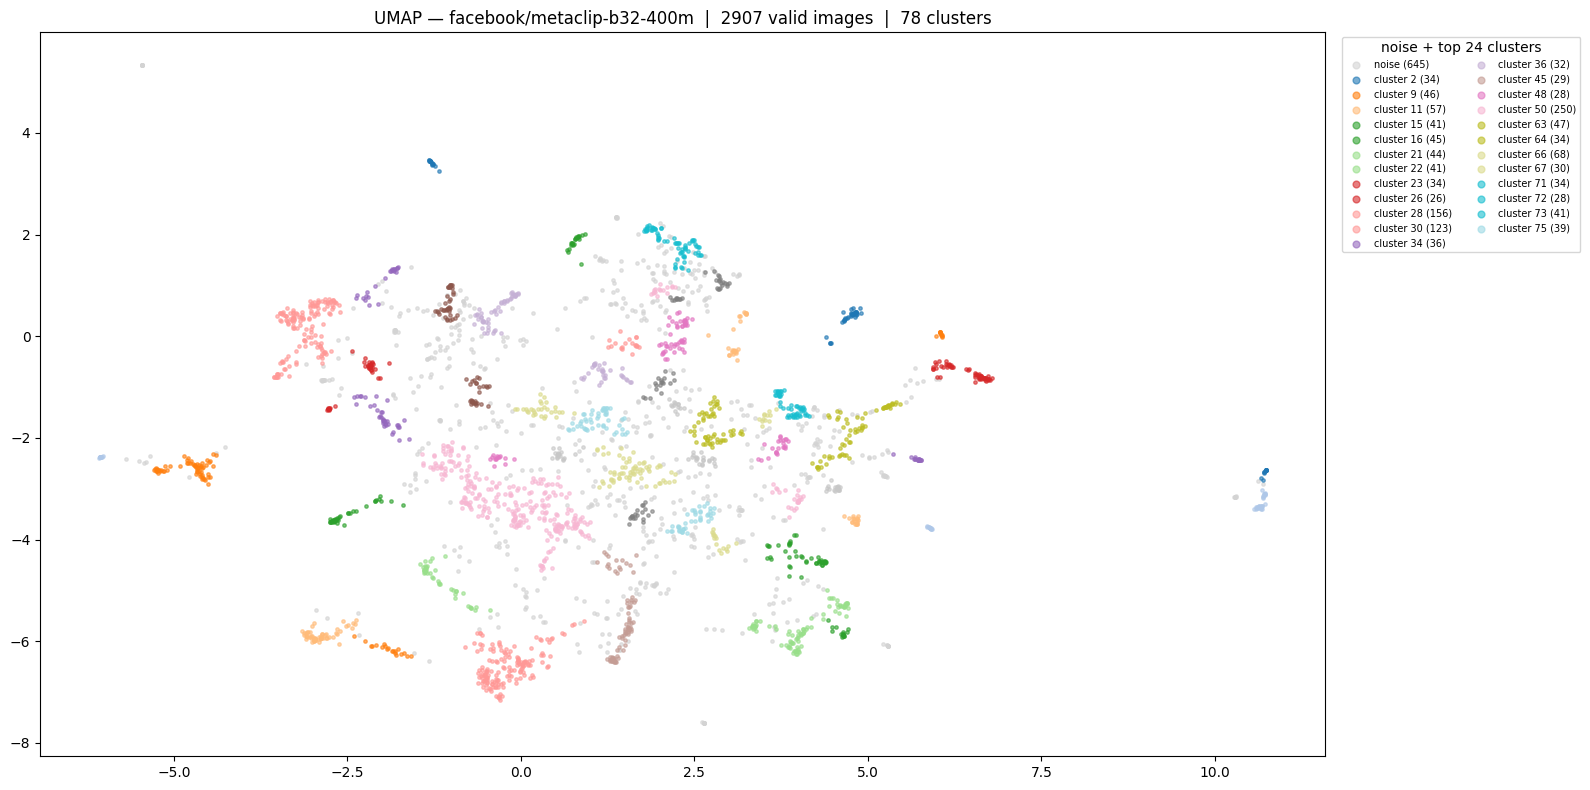

In [12]:
ACTIVE_MODEL = "facebook/metaclip-b32-400m"
UMAP_FIG_W   = 16
UMAP_FIG_H   = 8
LEGEND_TOP   = 24


def plot_clusters(model_name: str = ACTIVE_MODEL):
    run       = model_runs[model_name]
    emb2d     = run["embedding_2d"]
    labels    = run["labels"]
    paths     = [all_paths[i] for i in run["valid_indices"]]

    unique    = sorted(set(labels))
    cmap      = plt.cm.get_cmap("tab20", len(unique))
    sizes     = {cid: int((labels == cid).sum()) for cid in unique}
    legend_ids = [-1] + [
        cid for cid, _ in sorted(
            ((cid, sizes[cid]) for cid in unique if cid != -1),
            key=lambda x: x[1], reverse=True,
        )[:LEGEND_TOP]
    ]

    fig, ax = plt.subplots(figsize=(UMAP_FIG_W, UMAP_FIG_H))
    for i, cid in enumerate(unique):
        mask  = labels == cid
        color = "lightgrey" if cid == -1 else cmap(i)
        lbl   = None
        if cid in legend_ids:
            lbl = f"noise ({mask.sum()})" if cid == -1 else f"cluster {cid} ({mask.sum()})"
        ax.scatter(emb2d[mask, 0], emb2d[mask, 1], s=6, color=color, label=lbl, alpha=0.6)

    n_clusters = len(unique) - (1 if -1 in unique else 0)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=7, markerscale=2, ncol=2,
              title=f"noise + top {LEGEND_TOP} clusters")
    ax.set_title(f"UMAP — {model_name}  |  {len(paths)} valid images  |  {n_clusters} clusters")
    plt.tight_layout()
    plt.show()


def plot_hits(hits: list[dict], columns: int = 4, label: str = ""):
    if not hits:
        return
    rows = int(np.ceil(len(hits) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 2.4, rows * 2.4))
    axes = np.atleast_1d(axes).ravel()
    for ax, hit in zip(axes, hits):
        with Image.open(hit["path"]) as img:
            ax.imshow(img)
        ax.set_title(f"{hit['score']:.0f}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(hits):]:
        ax.axis("off")
    if label:
        fig.suptitle(label, fontsize=10)
    plt.tight_layout()
    plt.show()


def inspect_cluster(cid: int, model_name: str = ACTIVE_MODEL, k: int = 12):
    run    = model_runs[model_name]
    labels = run["labels"]
    paths  = [all_paths[i] for i in run["valid_indices"]]
    idx    = [i for i, c in enumerate(labels) if c == cid]
    sample = np.random.RandomState(SEED).choice(idx, size=min(k, len(idx)), replace=False)
    hits   = [{"path": paths[i], "score": float(labels[i] == cid)} for i in sample]
    plot_hits(hits, columns=4, label=f"{model_name} — cluster {cid} (n={len(idx)})")


def cluster_summary(
    model_name: str = ACTIVE_MODEL,
    k: int = 8,
    columns: int = 4,
    skip_noise: bool = True,
):
    run    = model_runs[model_name]
    labels = run["labels"]
    paths  = [all_paths[i] for i in run["valid_indices"]]
    unique = sorted(c for c in set(labels) if not (skip_noise and c == -1))
    for cid in unique:
        idx    = [i for i, c in enumerate(labels) if c == cid]
        sample = np.random.RandomState(SEED).choice(idx, size=min(k, len(idx)), replace=False)
        hits   = [{"path": paths[i], "score": float(labels[i] == cid)} for i in sample]
        plot_hits(hits, columns=columns, label=f"{model_name} — cluster {cid} (n={len(idx)})")


plot_clusters()
# inspect_cluster(6)
# cluster_summary()

# Vision Model Clustering

## Benchmark Corpus

2904 screenshots, shuffled with a fixed seed. All models were benchmarked on a 12-core laptop CPU with no GPU. Two images were unreadable across all models. The effective working set is 2902 valid images.

---

## Throughput

Measured on a 20-image sample. Projected to full corpus:

| Model                      | sec/image | est. full run |
|:---------------------------|-----------|---------------|
| MetaCLIP-b32               | 0.090     | ~4.3 min      |
| CLIP-base-patch32          | 0.098     | ~4.7 min      |
| DINOv2-small               | 0.102     | ~4.9 min      |
| CLIP-base-patch16          | 0.185     | ~8.9 min      |
| MobileCLIP-B               | 0.271     | ~13.1 min     |
| SigLIP-base-patch16-224    | 0.279     | ~13.5 min     |
| SigLIP-base-patch16-256    | 0.356     | ~17.2 min     |
| CLIP-large-patch14         | 0.965     | ~46.7 min     |
| SigLIP-large-patch16-256   | 1.219     | ~59.0 min     |
| CLIP-large-patch14-336     | 2.182     | ~105.6 min    |
| SigLIP-so400m-patch14-384  | 3.692     | ~178.7 min    |

The cost gradient is non-linear. The fast tier (MetaCLIP, CLIP-b32, DINOv2) all run under 5
minutes for a full corpus. The mid tier (MobileCLIP, SigLIP-base variants) runs 13-17 minutes.
The large tier starts at 47 minutes and scales to nearly 3 hours. SigLIP-so400m is a
non-starter on CPU-only hardware regardless of quality.

For incremental embedding of new images, per-image cost even at the large end (~2s) is
acceptable as a background task, comparable to other homelab media processing pipelines (Plex
Skip Intro, Immich facial recognition).

---

## Cluster Structure with OpenAI CLIP baseline

HDBSCAN over UMAP-reduced embeddings. Parameters held constant across all models. Core points are those assigned a non-noise label by both models in a given pair.

### Noise Rates (OpenAI)

| Model                      | Clusters | Noise points | Noise rate |
|:---------------------------|----------|--------------|------------|
| CLIP-base-patch32          | 97       | 703          | 24.2%      |
| CLIP-base-patch16          | 102      | 661          | 22.8%      |
| CLIP-large-patch14         | 87       | 579          | 20.0%      |
| CLIP-large-patch14-336     | 92       | 559          | 19.3%      |

Large models rescue ~140 images from noise relative to base32--approximately 4-5% of the corpus.  The assignments in the rescued set are lower-confidence by definition.

### Cross-Model Agreement (OpenAI)

ARI on all shared valid points (ari_all) is consistently low (0.11-0.23). ARI restricted to the points both models commit to as non-noise (ari_core) is substantially higher (0.51-0.71). The gap is structural: UMAP produces different 2D projections per model and HDBSCAN's noise boundary shifts with density topology. The points that both models commit to are genuinely stable; disagreement concentrates at the cluster boundary.

Within-family pairs score highest on pair Jaccard, as one should expect. The base pair (0.558) outscores the large pair (0.546) despite higher noise. The base models make smaller, tighter clusters that agree more precisely on co-membership. Larger models do not produce more internally consistent clustering.

---

## Extended Model Comparison

### Cross-Family Jaccard

The critical signal to study is cross-family Jaccard. What is the agreement between models that do not share training weights or architecture? 

Within-family agreement, while structurally expected, tells you nothing about whether a model's clusters reflect the data rather than its own inductive biases.

Top cross-family pairs:

| Pair                              | pair_jaccard |
|:----------------------------------|--------------|
| SigLIP-b256 / MetaCLIP            | 0.465        |
| SigLIP-b256 / MobileCLIP          | 0.464        |
| MetaCLIP / MobileCLIP             | 0.457        |
| CLIP-L14 / MobileCLIP             | 0.454        |
| CLIP-L14 / SigLIP-b256            | 0.433        |

The top three pairs form a closed triangle: MetaCLIP, SigLIP-base-256, and MobileCLIP all cross-agree at 0.46-0.47 Jaccard. None of the other model simplexes at comparable cost achieve this level of mutual agreement across different families and training data.

### DINOv2

DINOv2-small is the fastest model in the set but structurally isolated--every pair score falls between 0.12 and 0.18 regardless of partner. This is not noise-floor artifact. DINOv2 is self-supervised with no text-image pairing; its feature space organizes around visual similarity patterns orthogonal to the text-grounded representations every other model here uses. 

DINOv2 will not ensemble usefully with any of the other models for clustering consensus. Whether its orthogonal feature space has independent value for this corpus is an open question that requires separate evaluation. [**TODO**]

### MobileCLIP

Despite Apple's CPU-optimization marketing, MobileCLIP-B is slower than MetaCLIP and
CLIP-base32 in this benchmark (0.271 vs 0.090 sec/image). Its cross-family agreement pattern
aligns with MetaCLIP and SigLIP rather than with OpenAI CLIP, reflecting its DataCompDR
training lineage. It is not a drop-in for base32.

### The Efficiency Frontier

Plotting mean cross-family Jaccard against sec/image reveals the Pareto front directly: **MetaCLIP**, **MobileCLIP**, and **SigLIP-b256**. These three models are not dominated. No other model achieves better consensus at lower cost. 

Every other model in the set, including all large models, sits below the front: slower and worse cross-family agreement simultaneously. The large CLIP and SigLIP models in particular are expensive and score lower cross-family Jaccard than the front, making them unjustifiable on these metrics alone.

---

## Multi-Model Consensus Strategy

Models embed into different vector spaces (MetaCLIP: 512d, SigLIP: 768d, MobileCLIP: 512d). Outputs cannot be blended or refined incrementally: a model switch requires full re-embed and re-cluster. Storage cost for multiple embedding sets is negligible.

The value of running multiple models is not combining embedding spaces but treating cluster assignment agreement as a confidence signal:

- Non-noise and co-clustered in all three Pareto models: high-confidence assignment.
- Non-noise in one or two but not all three: usable, lower confidence.
- Noise in all three: no label assigned.

Cluster identity maps through image identity, not cluster index. The valid_indices alignment in the existing pipeline handles this correctly.

The three-model Pareto simplex (MetaCLIP + SigLIP-b256 + MobileCLIP) covers the full consensus surface with a combined full-corpus runtime under 35 minutes and no shared training weights across any pair.

---

## The Labeling Problem and `bruki`'s Value Prop

In practice, within-cluster purity for a semantic category like "receipts" is approximately 60%. The remaining 40% is not random--it reflects systematic co-clustering of visually similar but semantically distinct document types:

- receipts with invoices
- tickets with/without QR codes
- sports scores with weather

This is a feature space boundary problem that tighter cross-model consensus does not solve. The three-model consensus expands the confirmed-positive pool by increasing the non-noise set, but cluster identity alone cannot drive label propagation. 

**Therefore**, the necessary structure is a lightweight classifier trained directly in the embedding space on user-confirmed examples, with clusters serving as a bootstrapping surface to reduce the volume of images requiring human review.

Multi-label assignment compounds this. A screenshot can simultaneously be a receipt, a specific merchant, and a specific app's UI. Cluster membership does not decompose this naturally. This can only be learned from supervision, either human-in-the-middle or expensive AI-driven labeling of senstive data. Not ideal.

---

## Summary

**Default single model** MetaCLIP-b32. Fastest on the Pareto front, highest mean cross-family
Jaccard at the fast tier, full corpus under 5 minutes.

**Consensus layer** MetaCLIP + SigLIP-b256 + MobileCLIP. All three are on the Pareto front
with no shared weights. Combined runtime ~10 minutes per 1000 images on CPU. Mutual
cross-family Jaccard 0.46-0.47.

**Ruled out**
- Large CLIP and SigLIP models: dominated on the efficiency frontier, no consensus improvement.
- SigLIP-so400m: ~3 hours on CPU, not viable, not run on full corpus.
- DINOv2: orthogonal feature space, does not participate in clustering consensus.

**Limiting factor** Within-cluster semantic purity (~60%), independent of model choice.
Requires user-feedback-trained embedding-space classifier to address. Model selection affects
how efficiently the bootstrapping corpus is assembled, not the ceiling on label quality.